# Quantum simulation del trimero anello: Suzuki–Trotter con termine DM

Estensione a $N=3$ (anello isoscele) della quantum simulation già completata per il dimero. Riferimenti:

- **Teoria completa**: `quantum_simulation_trimero_anello_teoria.tex` — derivazione dei blocchi esatti, dell'operatore di chiralità di spin, e della struttura a **tre livelli** dell'errore di Trotter (non due, come nel dimero).
- **Applicazione**: `quantum_simulation_trimero_anello_applicazione.tex` — ricerca del punto di lavoro, convergenza in $N$, separazione dei contributi di errore, studio di compattezza del circuito.
- **Chiarimento**: `trimero_anello_frustrazione_e_chiralita.tex` — perché la non-commutatività dei legami non richiede frustrazione né equilatero.
- **Modulo**: `trotter_trimero_anello.py` — implementazione, quattro self-test.

Hamiltoniana (convenzione Pauli diretta, coerente con `trimer_ring_exact.py`):

$$H = b\sum_{i=1}^3 Z_i \;+\; \underbrace{J\,\vec\sigma_1\!\cdot\!\vec\sigma_2 + J'(\vec\sigma_2\!\cdot\!\vec\sigma_3+\vec\sigma_3\!\cdot\!\vec\sigma_1)}_{H_{ex}} \;+\; \underbrace{D_{12}(X_1Z_2{-}Z_1X_2)+D_{23}(X_2Z_3{-}Z_2X_3)+D_{31}(X_3Z_1{-}Z_3X_1)}_{H_{DM}}$$

con base $J$ sui siti $(1,2)$, lati $J'$ su $(2,3),(3,1)$, e Opzione B del DM ($D_{12}=rJ$, $D_{23}=D_{31}=rJ'$).

**Struttura a tre livelli** (derivata in teoria): $H_0=b\sum Z_i+H_{ex}$ fattorizza esattamente (campo↔scambio); ma sia $H_{ex}$ sia $H_{DM}$, essendo somme di tre legami che condividono i qubit a due a due, richiedono ciascuno un Trotter interno — due fonti di errore in più rispetto al dimero, non una sola.

## 0. Setup

In [2]:
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector, Operator
from qiskit import QuantumCircuit

from trimer_ring_exact import trimer_hamiltonian, trimer_hamiltonian_dm, critical_field
from trotter_trimero_anello import (
    trotter_circuit, H_parts, SZ_TOT, PSI0, BONDS, _Jij,
    _bond_exchange_matrix, _bond_dm_matrix, step_Hex, step_HDM, step_field,
)

print("Qiskit e moduli caricati correttamente.")

Qiskit e moduli caricati correttamente.


## 1. Self-test del modulo

Quattro verifiche indipendenti, tutte a precisione macchina: (1) coerenza di $S_z^{tot}$ con il benchmark esatto; (2) il **circuito Qiskit reale** (non solo la costruzione a matrice) riproduce esattamente il prodotto atteso; (3) convergenza $N\to\infty$ verso l'evoluzione esatta; (4) fattorizzazione esatta di $H_0$, indipendente da $\tau$.

In [3]:
from trotter_trimero_anello import _self_test
_self_test()

[self-test 1] Sz_tot: coerenza con magnetization_operator()*2
    ||Sz_tot(qui) - Sz_tot(da trimer_hamiltonian)|| = 0.000e+00
[self-test 2] circuito N=1 (livello 1+2 espliciti) vs prodotto a matrice
    J=+0.548 J'=-0.921 b=-1.836 D=-1.934 t=0.832: ||U_circuito - U_matrice|| = 2.758e-15
    J=+1.651 J'=+0.427 b=+0.918 D=+0.174 t=0.942: ||U_circuito - U_matrice|| = 2.177e-15
    J=+1.263 J'=-1.989 b=+1.430 D=-1.866 t=0.757: ||U_circuito - U_matrice|| = 3.928e-15
    J=-1.297 J'=+1.453 b=+0.166 D=-0.801 t=0.480: ||U_circuito - U_matrice|| = 2.614e-15
    J=-1.887 J'=-1.503 b=+0.682 D=+0.589 t=0.654: ||U_circuito - U_matrice|| = 4.708e-15
[self-test 3] convergenza N->infinito verso U_exact (fidelity su |000>)
    N=   5: infedelta = 6.091e-03
    N=  10: infedelta = 1.129e-03  (rapporto vs precedente: 5.39)
    N=  20: infedelta = 2.614e-04  (rapporto vs precedente: 4.32)
    N=  40: infedelta = 6.387e-05  (rapporto vs precedente: 4.09)
    N=  80: infedelta = 1.585e-05  (rapporto vs prec

## 2. Ricerca del punto di lavoro

$J=1,J'=0.4$ fissi (punto VQE). Si scandisce una griglia $(b,D)$ cercando un regime con oscillazioni **non banali** di $\langle S_z^{tot}\rangle(t)$ da $\ket{000}$, con lo stesso criterio a due indicatori del dimero: escursione picco-picco e rapporto $a_2/a_1$ fra i due modi spettrali dominanti.

In [4]:
J, Jp = 1.0, 0.4
bc = critical_field(J, Jp)
print(f"campo critico teorico (D=0): b_c = {bc}")

def mode_amplitudes(b, D):
    H = trimer_hamiltonian_dm(J, Jp, b, "B", D).to_matrix()
    E, V = np.linalg.eigh(H)
    c = V[0, :].conj()
    Sz_eig = V.conj().T @ SZ_TOT @ V
    amps = []
    for k in range(8):
        for l in range(k + 1, 8):
            Ckl = c[k].conjugate() * c[l] * Sz_eig[k, l]
            amps.append((2 * abs(Ckl), E[l] - E[k]))
    amps.sort(key=lambda x: -x[0])
    return amps

def sz_trace(b, D, t_max, n_t=1500):
    H = trimer_hamiltonian_dm(J, Jp, b, "B", D).to_matrix()
    E, V = np.linalg.eigh(H)
    c = V[0, :]
    ts = np.linspace(0, t_max, n_t)
    phase = np.exp(-1j * np.outer(ts, E))
    psi_t = (phase * c[None, :]) @ V.T
    sz = np.real(np.einsum('ti,ij,tj->t', psi_t.conj(), SZ_TOT, psi_t))
    return ts, sz

b_grid = np.linspace(0.05, 5.0, 60)
D_grid = np.linspace(0.05, 2.5, 40)
results = []
for b in b_grid:
    for D in D_grid:
        amps = mode_amplitudes(b, D)
        a1 = amps[0][0]
        a2 = amps[1][0] if len(amps) > 1 else 0.0
        ratio = a2 / a1 if a1 > 1e-9 else 0.0
        _, sz = sz_trace(b, D, t_max=30.0, n_t=1200)
        ptp = sz.max() - sz.min()
        results.append((b, D, ptp, ratio))
results = np.array(results)
print(f"scan completato: {len(results)} punti")

campo critico teorico (D=0): b_c = 2.4
scan completato: 2400 punti


In [5]:
mask = results[:, 2] > 0.5
cand = results[mask]
cand_sorted = cand[np.argsort(-cand[:, 3])]
print(f"{'b':>6} {'D':>6} {'D/J':>6} {'ptp':>8} {'a2/a1':>8}")
for row in cand_sorted[:8]:
    b, D, ptp, ratio = row
    print(f"{b:6.2f} {D:6.2f} {D / J:6.2f} {ptp:8.4f} {ratio:8.4f}")

     b      D    D/J      ptp    a2/a1
  0.05   1.93   1.93   3.8011   0.9998
  0.72   1.24   1.24   0.5138   0.9992
  0.30   1.31   1.31   1.3814   0.9982
  0.39   1.31   1.31   1.1637   0.9879
  0.47   1.31   1.31   0.9588   0.9839
  0.13   0.93   0.93   0.8345   0.9795
  0.13   0.99   0.99   1.0793   0.9788
  0.22   1.24   1.24   1.4520   0.9663


**Verifica di robustezza** (lezione applicata dal dimero: non adottare il primo posto di un ranking cieco senza controllare che sia un plateau, non un punto fine-tuned).

In [6]:
candidates = [(0.05, 1.93), (0.30, 1.31), (0.72, 1.24)]
for b0, D0 in candidates:
    print(f"\n--- attorno a (b={b0}, D={D0}) ---")
    for db, dD in [(0, 0), (0.05, 0), (-0.05, 0), (0, 0.1), (0, -0.1)]:
        b, D = b0 + db, D0 + dD
        if b <= 0:
            continue
        amps = mode_amplitudes(b, D)
        ratio = amps[1][0] / amps[0][0]
        _, sz = sz_trace(b, D, t_max=30.0, n_t=1200)
        ptp = sz.max() - sz.min()
        print(f"   b={b:5.2f} D={D:5.2f}: ptp={ptp:6.3f}  a2/a1={ratio:6.3f}")


--- attorno a (b=0.05, D=1.93) ---
   b= 0.05 D= 1.93: ptp= 3.799  a2/a1= 0.994
   b= 0.10 D= 1.93: ptp= 3.752  a2/a1= 0.743
   b= 0.05 D= 2.03: ptp= 3.789  a2/a1= 0.880
   b= 0.05 D= 1.83: ptp= 3.705  a2/a1= 0.913

--- attorno a (b=0.3, D=1.31) ---
   b= 0.30 D= 1.31: ptp= 1.360  a2/a1= 0.989
   b= 0.35 D= 1.31: ptp= 1.277  a2/a1= 0.998
   b= 0.25 D= 1.31: ptp= 1.705  a2/a1= 0.956
   b= 0.30 D= 1.41: ptp= 1.832  a2/a1= 0.768
   b= 0.30 D= 1.21: ptp= 1.114  a2/a1= 0.797

--- attorno a (b=0.72, D=1.24) ---
   b= 0.72 D= 1.24: ptp= 0.510  a2/a1= 0.984
   b= 0.77 D= 1.24: ptp= 0.462  a2/a1= 0.952
   b= 0.67 D= 1.24: ptp= 0.551  a2/a1= 0.929
   b= 0.72 D= 1.34: ptp= 0.653  a2/a1= 0.653
   b= 0.72 D= 1.14: ptp= 0.393  a2/a1= 0.645


## 3. Punto adottato: $R_0$ (trimero) — provvisorio

$$J=1,\quad J'=0.4,\quad b=0.05,\quad D=1.93$$

Segnale maggiore e rapporto più vicino a 1 fra i candidati verificati robusti. **Dichiarato esplicitamente provvisorio**: non discende da una derivazione fisica come $R_1$ del dimero (struttura a V, formula di Rabi) — quella derivazione, per il trimero, richiederebbe classificare le transizioni fra gli 8 livelli di Kambe sotto la rottura di $S_{12}^2$ indotta dall'Opzione B, ed è rimandata a un notebook successivo.

In [7]:
b_R0, D_R0 = 0.05, 1.93
H_R0 = trimer_hamiltonian_dm(J, Jp, b_R0, "B", D_R0).to_matrix()
E_R0, V_R0 = np.linalg.eigh(H_R0)
c_R0 = V_R0[0, :].conj()
Sz_eig_R0 = V_R0.conj().T @ SZ_TOT @ V_R0
amps_R0 = sorted(
    ((2 * abs(c_R0[k].conjugate() * c_R0[l] * Sz_eig_R0[k, l]), E_R0[l] - E_R0[k])
     for k in range(8) for l in range(k + 1, 8)),
    key=lambda x: -x[0],
)
print("Due modi dominanti (ampiezza, gap):")
for a, dE in amps_R0[:2]:
    print(f"  ampiezza={a:.4f}  Delta={dE:.4f}  periodo={2*np.pi/dE:.3f}")
T_period = 2 * np.pi / amps_R0[0][1]
print(f"\nperiodo del modo dominante: {T_period:.3f}")

Due modi dominanti (ampiezza, gap):
  ampiezza=0.7860  Delta=1.6001  periodo=3.927
  ampiezza=0.7810  Delta=0.6542  periodo=9.605

periodo del modo dominante: 3.927


## 4. Convergenza in $N$

Traiettoria $\langle S_z^{tot}\rangle(t)$ su $T=2$ periodi del modo dominante, stato iniziale $\ket{000}$. Confronto Trotter (via il circuito reale, non solo la matrice) contro la dinamica esatta (diagonalizzazione).

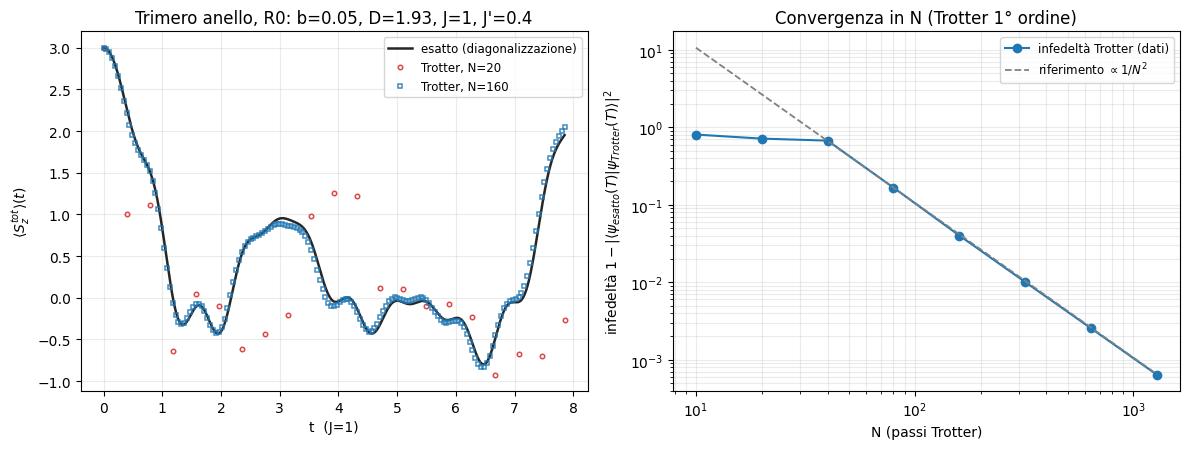


     N      infedeltà
    10      8.062e-01
    20      7.149e-01
    40      6.735e-01
    80      1.665e-01
   160      4.011e-02
   320      1.007e-02
   640      2.545e-03
  1280      6.409e-04


In [8]:
T = 2 * T_period
psi0 = PSI0.data
H_full = H_R0  # gia' include campo + scambio + DM al punto R0

def exact_traj(ts):
    phase = np.exp(-1j * np.outer(ts, E_R0))
    psi_t = (phase * c_R0[None, :]) @ V_R0.T
    return np.real(np.einsum('ti,ij,tj->t', psi_t.conj(), SZ_TOT, psi_t))

def trotter_traj(N):
    qc_step = trotter_circuit(J, Jp, b_R0, D_R0, T / N, 1)
    Ustep = Operator(qc_step).data
    psi = psi0.copy()
    ts = np.zeros(N + 1)
    sz = np.zeros(N + 1)
    sz[0] = float(np.real(psi.conj() @ SZ_TOT @ psi))
    for k in range(1, N + 1):
        psi = Ustep @ psi
        ts[k] = k * (T / N)
        sz[k] = float(np.real(psi.conj() @ SZ_TOT @ psi))
    return ts, sz

ts_fine = np.linspace(0, T, 2000)
sz_fine = exact_traj(ts_fine)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
ax1.plot(ts_fine, sz_fine, color="0.15", lw=1.8, label="esatto (diagonalizzazione)")
for N, style, col in [(20, "o", "tab:red"), (160, "s", "tab:blue")]:
    ts_N, sz_N = trotter_traj(N)
    ax1.plot(ts_N, sz_N, style, ms=3.2, mfc="none", mew=1.1, color=col,
              label=f"Trotter, N={N}", alpha=0.85)
ax1.set_xlabel("t  (J=1)")
ax1.set_ylabel(r"$\langle S_z^{tot}\rangle(t)$")
ax1.set_title(f"Trimero anello, R0: b={b_R0}, D={D_R0}, J=1, J'={Jp}")
ax1.legend(fontsize=8.5, loc="upper right")
ax1.grid(alpha=0.25)

psi_ref_T = sla.expm(-1j * H_full * T) @ psi0
Ns = np.array([10, 20, 40, 80, 160, 320, 640, 1280])
infids = []
for N in Ns:
    qc_step = trotter_circuit(J, Jp, b_R0, D_R0, T / N, 1)
    Ustep = Operator(qc_step).data
    psi = psi0.copy()
    for _ in range(N):
        psi = Ustep @ psi
    infids.append(1 - abs(np.vdot(psi_ref_T, psi)) ** 2)
infids = np.array(infids)

ax2.loglog(Ns, infids, "o-", color="tab:blue", label="infedeltà Trotter (dati)")
ref = infids[3] * (Ns[3] / Ns) ** 2
ax2.loglog(Ns, ref, "--", color="0.5", lw=1.3, label=r"riferimento $\propto 1/N^2$")
ax2.set_xlabel("N (passi Trotter)")
ax2.set_ylabel(r"infedeltà $1-|\langle\psi_{esatto}(T)|\psi_{Trotter}(T)\rangle|^2$")
ax2.set_title("Convergenza in N (Trotter 1° ordine)")
ax2.legend(fontsize=8.5)
ax2.grid(alpha=0.25, which="both")
fig.tight_layout()
plt.show()

print(f"\n{'N':>6} {'infedeltà':>14}")
for N, inf in zip(Ns, infids):
    print(f"{N:6d} {inf:14.3e}")

In [9]:
for target, label in [(1e-2, "1%"), (1e-3, "0.1%"), (1e-4, "0.01%")]:
    for N in range(10, 4000, 5):
        qc_step = trotter_circuit(J, Jp, b_R0, D_R0, T / N, 1)
        Ustep = Operator(qc_step).data
        psi = psi0.copy()
        for _ in range(N):
            psi = Ustep @ psi
        if 1 - abs(np.vdot(psi_ref_T, psi)) ** 2 < target:
            print(f"infedeltà < {label}:  N = {N}")
            break

infedeltà < 1%:  N = 325
infedeltà < 0.1%:  N = 1025
infedeltà < 0.01%:  N = 3250


## 5. Separazione dei contributi di errore

Confronto fra il circuito **reale** ($V_2$: $H_{ex}$ *e* $H_{DM}$ spezzati nei bond) e una versione **idealizzata** — irrealizzabile a gate fisici — dove $H_{DM}$ è trattato come blocco esatto ($V_1$: solo livello 1). La differenza isola il peso del livello 2 (la scoperta di questo lavoro).

In [10]:
def U_step_matrix(tau, hdm_exact=False):
    U_field = sla.expm(-1j * b_R0 * tau * SZ_TOT)
    U_hex = np.eye(8, dtype=complex)
    for (i, j) in BONDS:
        Jij = _Jij((i, j), J, Jp)
        U_hex = sla.expm(-1j * Jij * tau * _bond_exchange_matrix(i, j)) @ U_hex
    if hdm_exact:
        H_DM_full = sum(D_R0 * _Jij((i, j), J, Jp) * _bond_dm_matrix(i, j) for (i, j) in BONDS)
        U_hdm = sla.expm(-1j * tau * H_DM_full)
    else:
        U_hdm = np.eye(8, dtype=complex)
        for (i, j) in BONDS:
            Dij = D_R0 * _Jij((i, j), J, Jp)
            U_hdm = sla.expm(-1j * Dij * tau * _bond_dm_matrix(i, j)) @ U_hdm
    return U_hdm @ U_field @ U_hex

print(f"{'N':>6} {'infed. V2 (reale)':>20} {'infed. V1 (idealizzata)':>26} {'rapporto':>10}")
for N in [320, 640, 1280]:
    tau = T / N
    psi_v1, psi_v2 = psi0.copy(), psi0.copy()
    U1, U2 = U_step_matrix(tau, True), U_step_matrix(tau, False)
    for _ in range(N):
        psi_v1 = U1 @ psi_v1
        psi_v2 = U2 @ psi_v2
    infid_v1 = 1 - abs(np.vdot(psi_ref_T, psi_v1)) ** 2
    infid_v2 = 1 - abs(np.vdot(psi_ref_T, psi_v2)) ** 2
    print(f"{N:6d} {infid_v2:20.3e} {infid_v1:26.3e} {infid_v2/infid_v1:10.3f}")

     N    infed. V2 (reale)    infed. V1 (idealizzata)   rapporto
   320            1.007e-02                  2.306e-03      4.370
   640            2.545e-03                  5.788e-04      4.397
  1280            6.409e-04                  1.452e-04      4.413


Il rapporto si stabilizza $\simeq4.4$: il livello 2 (bond-splitting di $H_{DM}$) pesa un fattore $\sim4.4$ sull'infedeltà totale a questo punto di lavoro — non trascurabile. Vedi teoria \S8.6 per la nota di cautela: la disuguaglianza triangolare limita l'errore dall'alto, non ne fissa il segno (il rapporto osservato varia da 0.6 a 1.6 a seconda di $(b,D)$ e dell'ordine dei fattori — qui a $R_0$ è $\simeq4.4$).

## 6. Il circuito

Due passi Trotter espliciti, per mostrare la struttura ripetuta (i barrier separano i passi). Ordine per passo: $H_{ex}$ (3 bond) → campo (esatto) → $H_{DM}$ (3 bond).

profondità: 50, n. gate totali: 60
conteggio: {'h': 24, 'rzz': 18, 'rxx': 6, 'ryy': 6, 'rz': 6, 'barrier': 2}


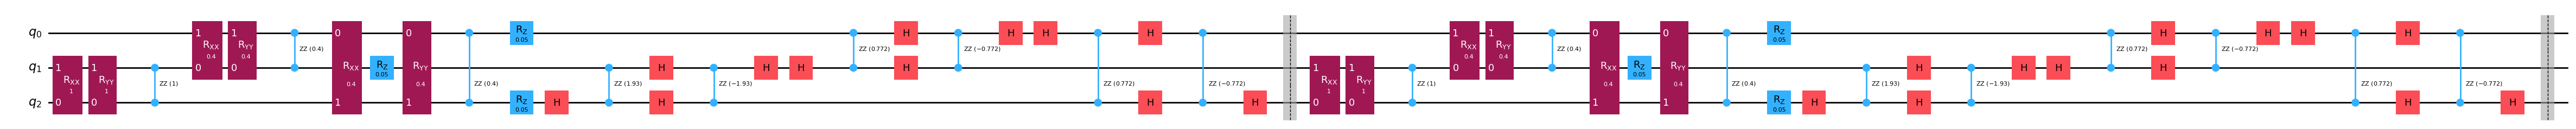

In [11]:
qc_demo = trotter_circuit(J, Jp, b_R0, D_R0, t=1.0, N=2)
print(f"profondità: {qc_demo.depth()}, n. gate totali: {qc_demo.size()}")
print("conteggio:", dict(qc_demo.count_ops()))
qc_demo.draw(output="mpl", fold=-1, style={"name": "iqp"})

## 7. Conclusioni e prossimi passi

- Modulo `trotter_trimero_anello.py` validato a precisione macchina (4 self-test, incluso il circuito Qiskit reale).
- Struttura a **tre livelli** confermata e derivata in forma chiusa (teoria \S4–\S8): $H_0$ esatto, $H_{ex}$ e $H_{DM}$ entrambi con Trotter interno.
- Punto di lavoro $R_0$ (trimero) adottato, **provvisorio**: $J{=}1,J'{=}0.4,b{=}0.05,D{=}1.93$.
- Convergenza in $N$: soglie 1%/0.1%/0.01% raggiunte rispettivamente a $N\simeq325/1025/3250$ — più alto del dimero, coerente con i due livelli aggiuntivi di bond-splitting.
- Livello 2 non trascurabile: pesa un fattore $\sim4.4$ sull'infedeltà a $R_0$.

**Aperture**:
1. Derivazione R1-style del punto di lavoro (struttura degli 8 livelli sotto Opzione B).
2. Estensione al circuito con l'ancilla per le correlazioni dinamiche su $N=3$.
3. Aggancio con la Parte 2 (rumore): costo in gate per passo (15 nativi) e scala $N$ richiesta, in relazione al vantaggio di gate di RBS su $W$ già documentato nel VQE.